In [2]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import datetime as dt
from functools import partial
from concurrent.futures import ThreadPoolExecutor

from scipy.interpolate import griddata

from tqdm import tqdm

In [3]:
# Define data directories
# base_data_dir = '/srv/scratch/z5370003/projects/data/groundwater/FEFLOW/coastal/variable_density/' # Uncomment for HPC
# base_data_dir = os.path.expanduser('~/Projects/groundwater/data/feflow_data') # Uncomment for local testing
base_data_dir = '/scratch/yl75/ak4177/data/feflow_data'

raw_data_dir = os.path.join(base_data_dir, 'all')
forcings_data_dir = os.path.join(base_data_dir, 'forcings_corrected_all')

print(f"Base data directory: {base_data_dir}, exists: {os.path.exists(base_data_dir)}")
print(f"Raw data directory: {raw_data_dir}, exists: {os.path.exists(raw_data_dir)}")
print(f"Forcings data directory: {forcings_data_dir}, exists: {os.path.exists(forcings_data_dir)}")


Base data directory: /scratch/yl75/ak4177/data/feflow_data, exists: True
Raw data directory: /scratch/yl75/ak4177/data/feflow_data/all, exists: True
Forcings data directory: /scratch/yl75/ak4177/data/feflow_data/forcings_corrected_all, exists: True


In [4]:
# Get and sort time series files
ts_files = sorted(os.listdir(raw_data_dir))
print(f"Total number of files: {len(ts_files)}")
print(f"First 3 files: {ts_files[:3]}")
print(f"Last 3 files: {ts_files[-3:]}")

Total number of files: 1909
First 3 files: ['0000.csv', '0001.csv', '0002.csv']
Last 3 files: ['1906.csv', '1907.csv', '1908.csv']


In [5]:
patch_data_dir = os.path.join(base_data_dir, 'masked_patch_all_ts')

In [6]:
target_cols = ['mass_concentration', 'head', 'pressure']
forcing_cols = ['mass_concentration_bc', 'head_bc', 'recharge_forcing', 'sea_level_forcing']
coords_cols = ['X', 'Y', 'Z']

# Tune this based on your storage and CPU. For network storage, fewer workers can be faster.
max_workers = min(12, os.cpu_count() or 1)
print(f'Parallelising across {max_workers}..')


Parallelising across 12..


In [7]:
ts_files = [ts_file for ts_file in ts_files if not ts_file.startswith('.')]

# Read node order and coordinates once; assumes row/node order is consistent across all files.
first_ts_df = pd.read_csv(
    os.path.join(raw_data_dir, ts_files[0]),
    low_memory=False,
 )[['node'] + coords_cols + target_cols]
node_to_idx = pd.Series(np.arange(len(first_ts_df)), index=first_ts_df['node']).to_dict()

first_ts_df

,node,X,Y,Z,mass_concentration,head,pressure
0,1,355744.543946,6.458162e+06,-10.000000,35000.00000,0.245000,100.448332
1,2,355786.688697,6.458049e+06,-10.000000,35000.00000,0.245000,100.448332
2,3,355828.833448,6.457936e+06,-9.840843,35000.00000,0.241101,98.849631
3,4,355870.978199,6.457823e+06,-7.901417,35000.00000,0.193585,79.368420
4,5,355913.122950,6.457710e+06,-5.150788,35000.00000,0.126194,51.738808
...,...,...,...,...,...,...,...
61355,61356,356266.259837,6.457027e+06,-40.000000,35000.00000,0.978723,401.780804
61356,61357,356232.471776,6.457012e+06,-40.000000,35000.00000,0.979232,401.785800
61357,61358,356221.893473,6.457040e+06,-40.000000,34999.99944,0.979226,401.785744
61358,61359,356199.733366,6.457047e+06,-40.000000,35000.00000,0.979483,401.788255


In [8]:
from tqdm import tqdm

# Accumulators for our running totals
n_counts = None
sum_x = None
sum_x2 = None

for ts_file in tqdm(ts_files):
    # 1. Read just the required columns and set index immediately
    ts_df = pd.read_csv(
        os.path.join(raw_data_dir, ts_file),
        usecols=['node', 'mass_concentration'],
        index_col='node',
        low_memory=False
    )['mass_concentration']
    
    # 2. Track valid data (handles NaN values if any exist)
    valid_mask = ts_df.notna()
    current_values = ts_df.fillna(0)
    current_squares = (ts_df ** 2).fillna(0)

    # 3. Add to our running totals
    if sum_x is None:
        sum_x = current_values
        sum_x2 = current_squares
        n_counts = valid_mask.astype(int)
    else:
        # .add() ensures exact node alignment across files
        sum_x = sum_x.add(current_values, fill_value=0)
        sum_x2 = sum_x2.add(current_squares, fill_value=0)
        n_counts = n_counts.add(valid_mask.astype(int), fill_value=0)

# 4. Calculate the standard deviation mathematically
# Pandas default std() uses sample standard deviation (Bessel's correction: n - 1)
variance = (sum_x2 - (sum_x ** 2) / n_counts) / (n_counts - 1)

# Prevent negative variances due to floating point precision errors near zero
variance = variance.clip(lower=0) 

# Standard deviation is the square root of the variance
node_std = np.sqrt(variance)

print(node_std)

100%|██████████| 1909/1909 [05:23<00:00,  5.90it/s]

node
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.000000
           ...   
61356    0.000000
61357    0.000506
61358    0.000000
61359    0.000000
61360    0.000000
Name: mass_concentration, Length: 61360, dtype: float64


In [9]:
first_ts_df['node_std'] = node_std

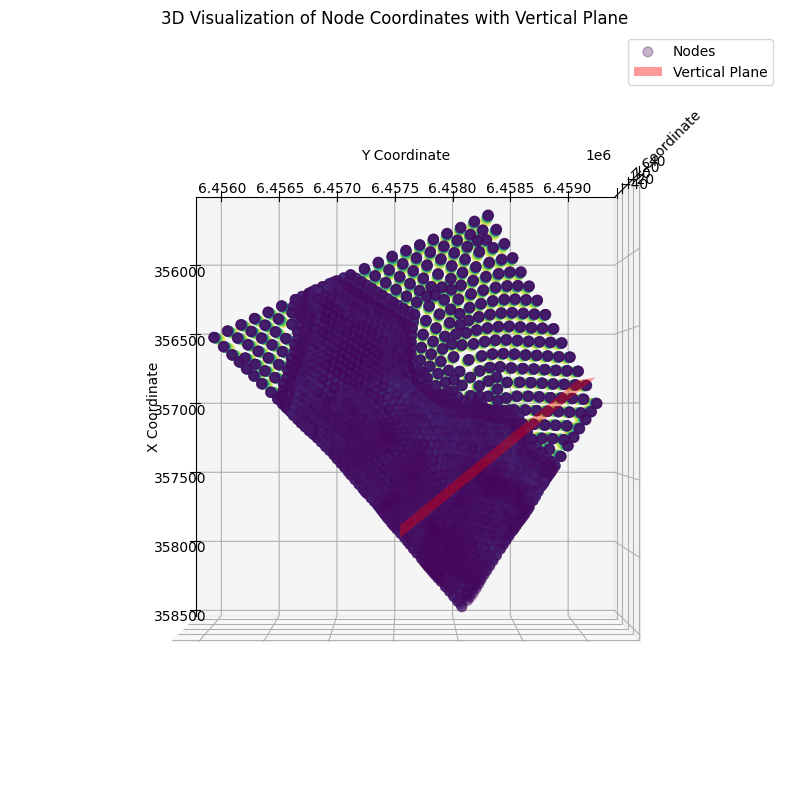

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming first_ts_df is already defined in your environment

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the original scatter data
ax.scatter(first_ts_df['X'], first_ts_df['Y'], first_ts_df['Z'], 
           c=first_ts_df['node'], marker='o', alpha=0.3, s=50, label='Nodes')

# 1. Define Points P1 and P2
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])

# 2. Create a 1D array of coordinates along the line between P1 and P2
x_line = np.linspace(p1[0], p2[0], 10)
y_line = np.linspace(p1[1], p2[1], 10)

# 3. Get the dynamic Z-limits from the scatter plot to properly scale the plane
z_min, z_max = ax.get_zlim()
z_line = np.linspace(z_min, z_max, 10)

# 4. Create 2D meshgrids required for plotting a surface
X_surf, Z_surf = np.meshgrid(x_line, z_line)
Y_surf, _ = np.meshgrid(y_line, z_line)

# 5. Plot the surface as a semi-transparent red plane
ax.plot_surface(X_surf, Y_surf, Z_surf, color='red', alpha=0.4, label='Vertical Plane')


# Set Labels and Title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Visualization of Node Coordinates with Vertical Plane')

# Note: plot_surface doesn't officially support standard legends in older matplotlib versions,
# but the scatter legend will still work perfectly.
ax.legend()

# Aspect Ratio
ax.set_box_aspect((1, 1, 1.1))

# View Angle
ax.view_init(elev=90, azim=0)

# Padding
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 5

plt.show()

In [11]:
import numpy as np

# 1. Define points and your mask boundaries (based on your script)
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])

mask_s_min, mask_s_max = 550, 800
mask_z_min, mask_z_max = -10, 5
plane_tolerance = 60  # Max distance (units) a point can be off the plane to be included

# 2. Calculate the unit vector of the plane line
line_vec = p2 - p1
line_len = np.linalg.norm(line_vec)
u = line_vec / line_len 

# 3. Create vectors from p1 to all points in the dataframe
v_x = first_ts_df['X'] - p1[0]
v_y = first_ts_df['Y'] - p1[1]

# 4. Calculate 's' (distance along the transect) and orthogonal distance from it
s_dist = v_x * u[0] + v_y * u[1]
ortho_dist = np.abs(v_x * u[1] - v_y * u[0])

# 5. Apply the mask directly to the dataframe
masked_df = first_ts_df[
    (s_dist >= mask_s_min) & (s_dist <= mask_s_max) & 
    (first_ts_df['Z'] >= mask_z_min) & (first_ts_df['Z'] <= mask_z_max) &
    (ortho_dist <= plane_tolerance)
].copy()

# 'masked_df' now contains only the 3D points inside your specific cross-section window.

In [12]:
line_vec, line_len

(array([ 1042.  , -1518.57]), np.float64(1841.6891281913124))

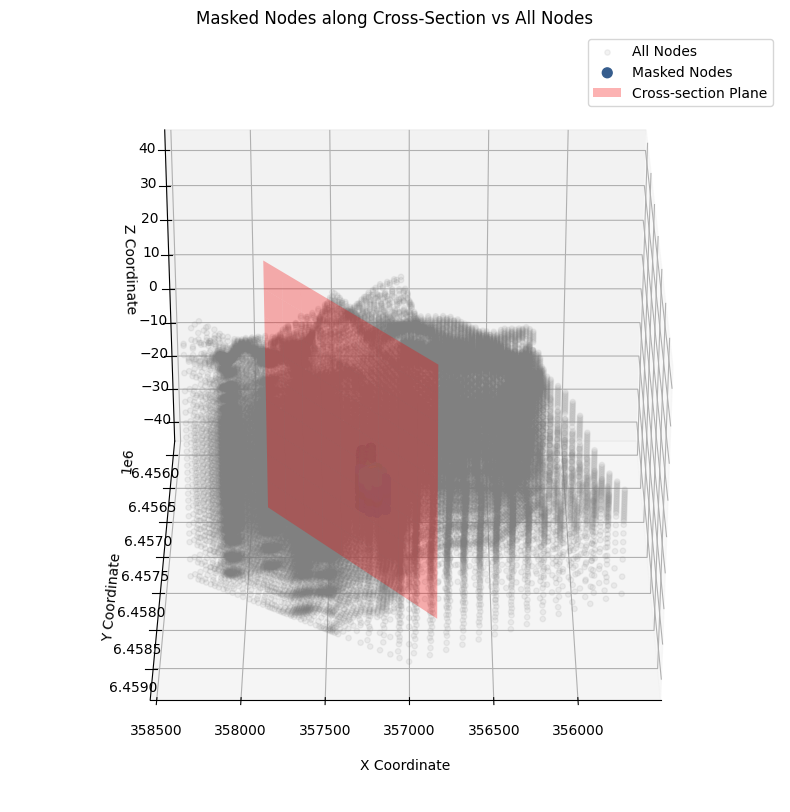

In [13]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# # 1. Plot all original nodes (faint grey in the background)
# # We use a very low alpha so they don't visually overwhelm the plot
ax.scatter(first_ts_df['X'], first_ts_df['Y'], first_ts_df['Z'], 
           c='grey', marker='o', alpha=0.1, s=15, label='All Nodes')

# 2. Plot the MASKED nodes (highlighted in red)
# High alpha and slightly larger size to make them pop
ax.scatter(masked_df['X'], masked_df['Y'], masked_df['Z'], 
           c=masked_df['node_std'], marker='o', alpha=1.0, s=50, label='Masked Nodes')

# 3. Draw the reference plane based on your exact mask boundaries
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])
mask_z_min, mask_z_max = -30, 40

# Create the surface grid
x_line = np.linspace(p1[0], p2[0], 10)
y_line = np.linspace(p1[1], p2[1], 10)
z_line = np.linspace(mask_z_min, mask_z_max, 10)

X_surf, Z_surf = np.meshgrid(x_line, z_line)
Y_surf, _ = np.meshgrid(y_line, z_line)

# Plot the plane (semi-transparent blue) AFTER the scatter plots 
# to help with Matplotlib's depth sorting
ax.plot_surface(X_surf, Y_surf, Z_surf, color='red', alpha=0.3, linewidth=10, label='Cross-section Plane')

# 4. Set Labels and Title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('Masked Nodes along Cross-Section vs All Nodes')

ax.legend()

# Aspect Ratio
# ax.set_box_aspect((1, 1, 1.1))

# View Angle
ax.view_init(elev=30, azim=90)

# Padding
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 5

plt.show()


In [48]:
def _load_timestep_for_patch(ts_file, core_idx, ghost_idx=None):
    
    ts_df = pd.read_csv(
        os.path.join(raw_data_dir, ts_file),
        low_memory=False,
    )[target_cols]
    
    ts_vals = ts_df.to_numpy()

    # Clip negative mass concentration values only (column 0 in target_cols).
    neg_mask = ts_vals[:, 0] < 0
    if np.any(neg_mask):
        ts_vals = ts_vals.copy()
        ts_vals[neg_mask, 0] = 0

    ts_forcings_df = pd.read_csv(
        os.path.join(forcings_data_dir, ts_file),
        low_memory=False,
    )[forcing_cols]
    
    forc_vals = ts_forcings_df.to_numpy()

    if ghost_idx is not None:
        return (
            ts_vals[core_idx, :],
            ts_vals[ghost_idx, :],
            forc_vals[core_idx, :],
            forc_vals[ghost_idx, :],
        )
    else:
        return (
            ts_vals[core_idx, :],
            forc_vals[core_idx, :],
        )

In [49]:
patch_config = {
    "1": {
        "core_nodes": masked_df.node.values.tolist(),
        "ghost_nodes": []
    }
}
# patch_config

In [51]:
for k, v in patch_config.items():
    # Get the patch configuration
    config = patch_config[k]

    # Print patch information
    print(f"\n({dt.datetime.now()}) Processing patch {k}")
    print(f"Patch {k} has {len(config['core_nodes'])} core nodes and {len(config['ghost_nodes'])} ghost nodes")
    # print(f"Patch {k} has {len(config['neighbour_patches'])} neighbour patches")
    # print(f"Patch {k} has {config['slice_group']} slice group")

    # Precompute row indices once per patch (much faster than repeated isin filtering).
    core_idx = np.array([node_to_idx[n] for n in config['core_nodes']], dtype=np.int64)
    ghost_idx = np.array([node_to_idx[n] for n in config['ghost_nodes']], dtype=np.int64)

    worker = partial(_load_timestep_for_patch, core_idx=core_idx, ghost_idx=ghost_idx)

    # Parallel load + slice for all timesteps in this patch.
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(worker, ts_files), total=len(ts_files)))

    # Convert to numpy arrays
    core_patch_data = np.nan_to_num(np.array([r[0] for r in results]))
    ghost_patch_data = np.nan_to_num(np.array([r[1] for r in results]))
    core_forcings_data = np.nan_to_num(np.array([r[2] for r in results]))
    ghost_forcings_data = np.nan_to_num(np.array([r[3] for r in results]))

    core_coords = first_ts_df.iloc[core_idx][coords_cols].values
    ghost_coords = first_ts_df.iloc[ghost_idx][coords_cols].values

    # Create directory for patch data
    patch_dir_path = os.path.join(patch_data_dir, f'patch_{int(k):03d}')
    os.makedirs(patch_dir_path, exist_ok=True)

    # Save the data
    np.save(os.path.join(patch_dir_path, 'core_obs.npy'), core_patch_data)
    np.save(os.path.join(patch_dir_path, 'ghost_obs.npy'), ghost_patch_data)
    np.save(os.path.join(patch_dir_path, 'core_coords.npy'), core_coords)
    np.save(os.path.join(patch_dir_path, 'ghost_coords.npy'), ghost_coords)
    np.save(os.path.join(patch_dir_path, 'core_forcings.npy'), core_forcings_data)
    np.save(os.path.join(patch_dir_path, 'ghost_forcings.npy'), ghost_forcings_data)


(2026-06-11 10:22:52.055651) Processing patch 1
Patch 1 has 346 core nodes and 0 ghost nodes


100%|██████████| 1909/1909 [01:30<00:00, 21.20it/s]


In [53]:
obs_data = np.load(os.path.join(patch_dir_path, 'core_obs.npy'))
forcings_data = np.load(os.path.join(patch_dir_path, 'core_forcings.npy'))
obs_data.shape, forcings_data.shape

((1909, 346, 3), (1909, 346, 4))

In [54]:
forcings_data.mean(axis=(0, 1))

array([1.20036063e+03, 2.61990718e-03, 3.47862697e-05, 2.19389742e-03])